# APRENDIZAGEM NÃO SUPERVISIONADA: AGRUPAMENTO (Clustering)
Este projeto desenvolve modelos de Machine Learning para segmentação de clientes de um shopping, visando identificar padrões de comportamento de consumo.

**Dataset:** [Mall Customers - Kaggle](https://www.kaggle.com/shwetabh123/mall-customers)

### 1. Configuração do Ambiente

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from kmodes.kprototypes import KPrototypes

# Configurações de visualização
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
%matplotlib inline

### 2. Carga e Inspeção dos Dados

In [6]:
# Carregamento (ajuste o caminho conforme seu ambiente)
df = pd.read_csv('Mall_Customers.csv', sep=',', encoding='iso-8859-1')

# Renomeando colunas para facilitar o acesso
df.columns = ['id', 'genero', 'idade', 'rendimento', 'pontuacao']

print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (200, 5)


,id,genero,idade,rendimento,pontuacao
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. Análise Exploratória (EDA)

Organize os gráficos por tipo de variável.

In [7]:
# Distribuição de Idade e Rendimento
fig = px.histogram(df, x="idade", nbins=30, title='Distribuição das Idades', marginal="box")
fig.show()

# Relação Rendimento vs Pontuação (Visualização Crítica para Clustering)
fig = px.scatter(df, x="rendimento", y="pontuacao", color="genero", 
                 hover_data=['idade'], title="Rendimento Anual vs Pontuação de Gastos")
fig.show()

### 4. Pré-processamento

In [8]:
# Seleção de atributos numéricos para algoritmos baseados em distância
X = df[['idade', 'rendimento', 'pontuacao']].values

# Normalização (Essencial para K-Means e Hierárquico)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Redução de Dimensionalidade (PCA) para Visualização 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### 5. Modelagem: K-Means (Exemplo de Organização)

Repita essa estrutura para os outros algoritmos (DBSCAN, Hierárquico).

  File "c:\Users\mau_a\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\mau_a\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mau_a\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mau_a\anaconda3\Lib\subprocess.

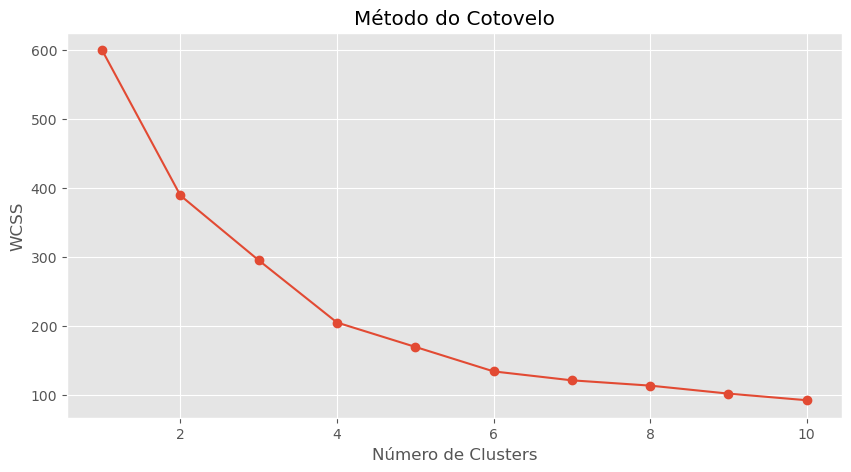

In [9]:
# Método do Cotovelo (Elbow Method) para definir K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Execução do Modelo Final
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)